In [ ]:
!pip install numpy pandas scikit-learn matplotlib seaborn
!pip install tensorflow


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


In [ ]:
from google.colab import files
uploaded = files.upload()  # Click "Choose File" and upload your CSV


Saving Fake.csv to Fake (2).csv
Saving True.csv to True (2).csv


In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()  # Shows first 5 rows


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


Let's perform some basic text cleaning on the `text` column of the `df` DataFrame, which includes converting all text to lowercase and filling any potential missing values. This is a common preprocessing step for text data.

In [ ]:
print(f"Missing values in 'text' column before cleaning: {df['text'].isnull().sum()}")
# Convert text to lowercase and fill any NaN values with an empty string
df['text'] = df['text'].str.lower().fillna('')
print(f"Missing values in 'text' column after cleaning: {df['text'].isnull().sum()}")
# Display the first few rows with the cleaned text
display(df[['text']].head())

Missing values in 'text' column before cleaning: 0
Missing values in 'text' column after cleaning: 0


,text
0,donald trump just couldn t wish all americans ...
1,house intelligence committee chairman devin nu...
2,"on friday, it was revealed that former milwauk..."
3,"on christmas day, donald trump announced that ..."
4,pope francis used his annual christmas day mes...


title      0
text       0
subject    0
date       0
label      0
dtype: int64


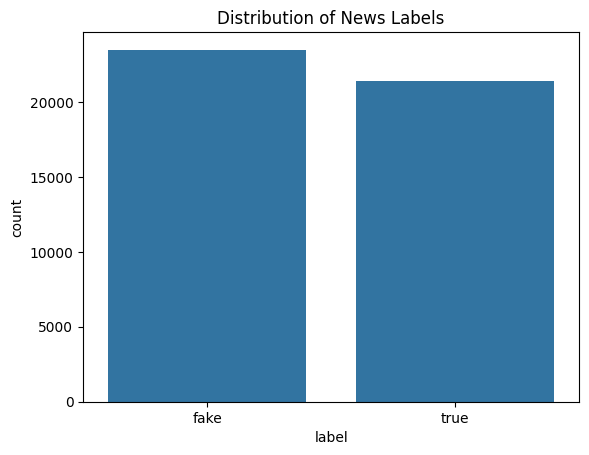

In [ ]:
# Load Fake news data and add a 'label' column
df_fake = pd.read_csv('Fake.csv')
df_fake['label'] = 'fake'

# Load True news data and add a 'label' column
df_true = pd.read_csv('True.csv')
df_true['label'] = 'true'

# Concatenate both dataframes
df = pd.concat([df_fake, df_true], ignore_index=True)

# Convert text to lowercase and fill any NaN values with an empty string (re-apply cleaning after concat)
df['text'] = df['text'].str.lower().fillna('')

# Check for missing values
print(df.isnull().sum())

# Drop missing values (if any, though 'text' is handled above)
df = df.dropna()

# Check distribution of labels
sns.countplot(x='label', data=df)
plt.title('Distribution of News Labels')
plt.show()

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X = vectorizer.fit_transform(df['text'])
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Accuracy: 0.9844097995545658
              precision    recall  f1-score   support

        fake       0.99      0.98      0.99      4733
        true       0.98      0.98      0.98      4247

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



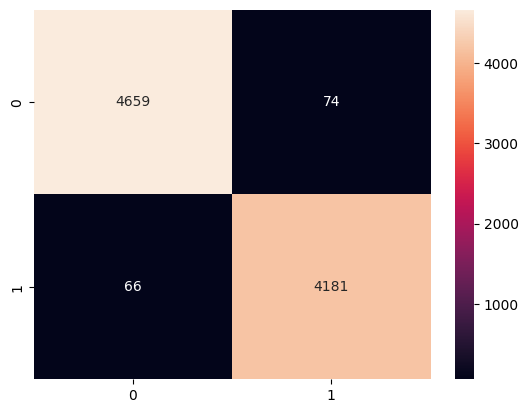

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()


In [ ]:
# Tokenize text
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])

# Pad sequences
maxlen = 100
X_seq = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=maxlen)

# Convert string labels to numerical (0 for 'fake', 1 for 'true')
y_seq = np.array([1 if label == 'true' else 0 for label in df['label']])

# Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# LSTM Model
model2 = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=maxlen),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.fit(X_train2, y_train2, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model2.evaluate(X_test2, y_test2)
print("Test Accuracy (DL model):", acc)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


449/449 ━━━━━━━━━━━━━━━━━━━━ 75s 156ms/step - accuracy: 0.9127 - loss: 0.2496 - val_accuracy: 0.9836 - val_loss: 0.0581
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 69s 154ms/step - accuracy: 0.9841 - loss: 0.0495 - val_accuracy: 0.9790 - val_loss: 0.0622
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 80s 150ms/step - accuracy: 0.9903 - loss: 0.0323 - val_accuracy: 0.9826 - val_loss: 0.0585
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 74s 164ms/step - accuracy: 0.9922 - loss: 0.0224 - val_accuracy: 0.9833 - val_loss: 0.0560
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 74s 147ms/step - accuracy: 0.9948 - loss: 0.0174 - val_accuracy: 0.9830 - val_loss: 0.0672
281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9820 - loss: 0.0812
Test Accuracy (DL model): 0.9841870665550232
